# In-situ Electrochemical SAXS analysis

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import glob
import os
import numpy as np
import pandas as pd
# import scienceplots
from galvani import BioLogic as BL
import eclabfiles as ecf
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display
from pybaselines import Baseline, utils
from scipy.signal import savgol_filter # Savitzky-Golay filter

# Define Functions

# Function for reading files 

In [3]:
import pandas as pd
import re

def read_data(file_name):
    legend_temp = None
    time_stamp_temp = None
    data_lines = []
    data_storing = False  # Flag to detect when to start reading data

    with open(file_name, 'r') as file:
        for line in file:
            line = line.strip()  # Remove leading/trailing spaces

            # Detect the last separator line and start storing data
            if line.startswith("################################################################################"):
                data_storing = True  # Start reading data after the last separator
                continue

            # Extract metadata
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2]
                
            # Store numerical data after the separator
            if data_storing and line and not line.startswith("#"):  # Ignore empty and comment lines
                data_lines.append(line)

    # Ensure we have data before processing
    if len(data_lines) < 2:  # Must have at least one data row + header
        print("No data found in the file!")
        return legend_temp, time_stamp_temp, None

    # Convert data into a DataFrame (handle variable spaces properly)
    df_temp = pd.DataFrame([re.split(r'\s+', line) for line in data_lines])

    # Assign correct column names from the first row
    df_temp.columns = df_temp.iloc[0]  # First row contains column names
    df_temp = df_temp[1:]  # Remove the header row from data

    # Convert numeric columns to float
    df_temp = df_temp.apply(pd.to_numeric, errors='coerce')

    return legend_temp, time_stamp_temp, df_temp



# Find files corresponding to Electrochemical events

In [4]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    
    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
    
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    
    return nearest_key, new_time_dict


# Read the variables file

In [5]:
# Initialize variables
directory_path = None
mpr_file_path = None
saxs_min_limit = None
saxs_max_limit = None
waxs_min_limit = None
waxs_max_limit = None

with open(r'E:\SAXS_WAXS\variables.txt', 'r') as file:
    lines = file.readlines()

for line in lines:
    stripped_line = line.strip()  # Remove leading/trailing whitespace and newlines
    
    # Skip comments and empty lines
    if not stripped_line or stripped_line.startswith("#"):
        continue
    
    if directory_path is None:
        directory_path = stripped_line
    elif mpr_file_path is None:
        mpr_file_path = stripped_line
    elif saxs_min_limit is None:
        saxs_min_limit = float(stripped_line)
    elif saxs_max_limit is None:
        saxs_max_limit = float(stripped_line)
    elif waxs_min_limit is None:
        waxs_min_limit = float(stripped_line)
    elif waxs_max_limit is None:
        waxs_max_limit = float(stripped_line)


# Example: Use the min and max limits
print(f"Files Directory path: {directory_path}")
print(f"SAXS Contourplot Limits: Min = {saxs_min_limit}, Max = {saxs_max_limit}")
print(f"WAXS Contourplot Limits: Min = {waxs_min_limit}, Max = {waxs_max_limit}")


Files Directory path: C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240820_2503SKJB_satDME_200HFE_120uL_1G1PS\cycle
SAXS Contourplot Limits: Min = 0.13, Max = 3.0
WAXS Contourplot Limits: Min = 22.0, Max = 30.0


# Function for the contour plots

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
from scipy.ndimage import gaussian_filter
import tkinter as tk
from tkinter import filedialog

def contourplot(plot_type, data_normalization, data_dictionary, new_time_dict, min_limit, max_limit, cmap_min=None, cmap_max=None, Normalization_file=None, save_plot=False, filename="contour_plot.png", decimal_points=2, scientific=False):
    # Constants
    wavelength_nm = 0.154  # Cu K-alpha wavelength in nm
    fntsize = 16  # Font size for labels
    plt.style.use('default')

    # Extracting time keys
    keys = list(new_time_dict.keys())
    time_t1 = []
    Intensity_list = []
    
    # Extract first file data
    X1_data_temp = 10 * data_dictionary[starting_file].iloc[:, 0]

    # Convert q to two-theta if plot_type is 'waxs'
    if plot_type == 'waxs':
        X1_data_temp = 2 * np.degrees(np.arcsin((wavelength_nm * X1_data_temp) / (4 * np.pi)))
        x_label = '2θ (°)'
    else:
        x_label = 'q (nm $^{-1}$)'

    # Filter data within range
    indices_within_range = np.where((X1_data_temp >= min_limit) & (X1_data_temp <= max_limit))
    X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
    start_row = np.min(indices_within_range)
    end_row = np.max(indices_within_range)

    # Process data
    for file_number in range(starting_file, last_file + 1):
        if data_normalization == 'relative':
            Y1_data = [(data_dictionary[file_number].iloc[start_row:end_row + 1, 1]) / data_dictionary[Normalization_file].iloc[start_row:end_row + 1, 1]]
        else:
            Y1_data = [(data_dictionary[file_number].iloc[start_row:end_row + 1, 1])]
        time_t1.append(float(keys[file_number - 1] - keys[starting_file - 1]))
        Intensity_list.append(list(Y1_data))
        capacity = [(t * applied_current) / (active_material_mass * 3.6) for t in time_t1]

    # Convert to numpy array
    normIntensity_array = np.array(Intensity_list)
    X, Y = np.meshgrid(X1_data_filtered_positions, capacity)
    normIntensity_flat = normIntensity_array[:, 0, :]
    smoothed_intensity = gaussian_filter(normIntensity_flat, sigma=1)  ## Apply Gaussian smoothing
    cmap1 = plt.colormaps.get_cmap('viridis')

    # Setup figure
    cycle_capacity = ((elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0]) * applied_current) / (active_material_mass * 3.6)
    min_capacity = cycle_capacity.min()
    max_capacity = cycle_capacity.max()
    fig, axs = plt.subplots(1, 2, figsize=(8, 10), sharey=True, gridspec_kw={'width_ratios': [1, 4]})

    # Left subplot: Potential vs Specific Capacity
    axs[0].plot(elec_df_2['Ewe/V'], cycle_capacity, color='r')
    axs[0].invert_xaxis()
    axs[0].set_ylabel('Specific capacity (mAh g$^{-1}$)', fontsize=fntsize)
    axs[0].set_xlabel('Potential (V)', fontsize=fntsize)
    axs[0].set_ylim(min_capacity, max_capacity)

    # Right subplot: Contour plot
    contour = axs[1].contourf(X, Y, smoothed_intensity, cmap=cmap1, vmin=cmap_min, vmax=cmap_max)

    # Create color bar
    cbar = fig.colorbar(contour, ax=axs[1])

    if data_normalization == 'relative':
        cbar.set_label('Relative Intensity', fontsize=fntsize)
    else:
        cbar.set_label('Intensity (a.u.)', fontsize=fntsize)  # Ensure proper font size

    # Get min, mid, max values for ticks
    cbar_min = cmap_min if cmap_min is not None else smoothed_intensity.min()
    cbar_max = cmap_max if cmap_max is not None else smoothed_intensity.max()
    cbar_mid = (cbar_min + cbar_max) / 2

    # Scale ticks by ×10⁴
    scale_factor = 1e4  # Change depending on data scale

    if scientific:
        scaled_min = cbar_min * scale_factor
        scaled_mid = cbar_mid * scale_factor
        scaled_max = cbar_max * scale_factor

    # Set ticks and tick labels with same font size
        cbar.set_ticks([cbar_min, cbar_mid, cbar_max])
        cbar.set_ticklabels([f"{scaled_min:.{decimal_points}f}", 
                            f"{scaled_mid:.{decimal_points}f}", 
                            f"{scaled_max:.{decimal_points}f}"], fontsize=fntsize)

    # **Manually add "×10⁴" at the top of the color bar with the same font size**
        cbar.ax.text(1.1, 1.02, "×10⁻⁴", transform=cbar.ax.transAxes, fontsize=12, ha='left', va='bottom')

    else:
        # Normal formatting (non-scientific mode)
        cbar.set_ticks([cbar_min, cbar_mid, cbar_max])
        tick_labels = [f"{cbar_min:.{decimal_points}f}", f"{cbar_mid:.{decimal_points}f}", f"{cbar_max:.{decimal_points}f}"]
        cbar.set_ticklabels(tick_labels, fontsize=fntsize)

    if plot_type == 'saxs':
        axs[1].set_xscale('log')
        axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
        
        # Generate major ticks (ensure min_limit and integer values)
        ticks = [min_limit] + list(range(int(np.ceil(min_limit)), int(max_limit) + 1, 2))
        tick_labels = [f'{ticks[0]:.1f}'] + [f'{tick:.1f}' for tick in ticks[1:]]
        
        axs[1].set_xticks(ticks)
        axs[1].set_xticklabels(tick_labels, fontsize=fntsize)

        # **Add minor ticks for values below 1**
        axs[1].xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], numticks=10))
        for label in axs[1].get_xticklabels():
            if label.get_text() == '0.1':
                label.set_x(label.get_position()[0] + 0.1)

    # Adjust subplot layout
    fig.subplots_adjust(wspace=0.05, left=0.15, right=0.85, top=0.85, bottom=0.2)
    axs[1].set_xlabel(x_label, fontsize=fntsize)

    axs[0].tick_params(axis='both', labelsize=fntsize)
    axs[1].tick_params(axis='both', labelsize=fntsize)

    # Optional save function
    if save_plot:
        root = tk.Tk()
        root.withdraw()
        save_path = filedialog.asksaveasfilename(defaultextension=".png", initialfile=filename, filetypes=[("PNG files", "*.png")])
        if save_path:
            plt.savefig(save_path, dpi=600)
            print(f"Plot saved to {save_path}")

    plt.show()


In [7]:
⁴", transform=cbar.ax.transAxes, fontsize=12, ha='left', va='bottom')

    else:
        # Normal formatting (non-scientific mode)
        cbar.set_ticks([cbar_min, cbar_mid, cbar_max])
        tick_labels = [f"{cbar_min:.{decimal_points}f}", f"{cbar_mid:.{decimal_points}f}", f"{cbar_max:.{decimal_points}f}"]
        cbar.set_ticklabels(tick_labels, fontsize=fntsize)

    if plot_type == 'saxs':
        axs[1].set_xscale('log')
        axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
        
        # Generate major ticks (ensure min_limit and integer values)
        ticks = [min_limit] + list(range(int(np.ceil(min_limit)), int(max_limit) + 1, 2))
        tick_labels = [f'{ticks[0]:.1f}'] + [f'{tick:.1f}' for tick in ticks[1:]]
        
        axs[1].set_xticks(ticks)
        axs[1].set_xticklabels(tick_labels, fontsize=fntsize)

        # **Add minor ticks for values below 1**
        axs[1].xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], numticks=10))
        for label in axs[1].get_xticklabels():
            if label.get_text() == '0.1':
                label.set_x(label.get_position()[0] + 0.1)

    # Adjust subplot layout
    fig.subplots_adjust(wspace=0.05, left=0.15, right=0.85, top=0.85, bottom=0.2)
    axs[1].set_xlabel(x_label, fontsize=fntsize)

    axs[0].tick_params(axis='both', labelsize=fntsize)
    axs[1].tick_params(axis='both', labelsize=fntsize)

    # Optional save function
    if save_plot:
        root = tk.Tk()
        root.withdraw()
        save_path = filedialog.asksaveasfilename(defaultextension=".png", initialfile=filename, filetypes=[("PNG files", "*.png")])
        if save_path:
            plt.savefig(save_path, dpi=600)
            print(f"Plot saved to {save_path}")

    plt.show()


SyntaxError: invalid character '⁴' (U+2074) (1607631568.py, line 1)

# Smooth the data

In [8]:
def smooth_data(data, window_length, polyorder):
    return savgol_filter(data, window_length, polyorder)

# Upload/read data files for SAXS

In [9]:
directory_path = r'\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\Cell3\data_reduction_with_applied_mask'
mpr_file_path = r'\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\Cell3\cell3_20250210_SKJB_0pt94_SatDME-HFE_100uL_1G1PS_diamond_window_with-tape_C02.mpr'
os.chdir(directory_path)
mpr = BL.MPRfile(mpr_file_path)

file_list = glob.glob('*_0_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)
    
print('Number of files:',key)

Number of files: 385


# Plot Data

In [ ]:

file_min = 5  # Start index of the files to plot
file_max = 350  # End index of the files to plot

plt.figure()
plt.style.use('default')

# Get 'viridis' colormap
cmap = plt.get_cmap('viridis')
files_to_plot = list(file_dictionary.keys())[file_min:file_max+1]  # Select keys in the specified range
num_files = len(files_to_plot)
colors = cmap(np.linspace(0, 1, num_files))  # Generate a range of colors for each selected file

# Plot each file in the specified range
for idx, (ikey, color) in enumerate(zip(files_to_plot, colors)):
    # print(f"Plotting file {ikey}...")
    X_data = 10 * file_dictionary[ikey].iloc[:, 0]  # Convert from inverse Å to inverse nm
    Y_data = file_dictionary[ikey].iloc[:, 1]
    plt.plot(X_data, Y_data, color=color, label=f"File {ikey}")

# Setting graph attributes
plt.xlim(0.01,3)
plt.ylim(0.0004,1000000)
plt.xlabel('q (nm $^{-1}$)', fontsize = 20)
plt.ylabel('Intensity (a.u.)', fontsize = 20)
plt.tick_params(labelsize = 20)

plt.xscale('log')
plt.yscale('log')

#plt.legend(title="Files", loc="best", fontsize="small", bbox_to_anchor=(1, 1))
#plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label='File Index', orientation='vertical')  # Optional: colorbar for reference
plt.show()


# Load electrochemical (EC Lab) file

Indices for cycle change [121, 4337, 8376, 12234, 15971, 19451, 22853, 26075, 29226, 30470]

Absolute times for change in electrochemical state: 
[120.00019696853997, 21187.679489594055, 41370.29756541207, 60648.49040132039, 79323.41294911958, 96713.25103571056, 113712.27301470487, 129807.33000758605, 145547.60677332478, 151763.1715458223]
Applied current 0.1573
Mass of active material 0.9391044502827659 mg


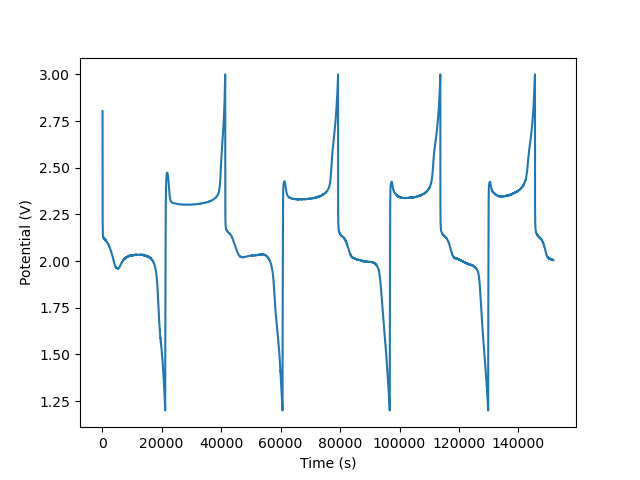

In [11]:
plt.figure()

elec_df_temp = pd.DataFrame(mpr.data)
rate = float(input("Enter discharge-charge rate, value of N in (C/N):"))

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0], 'time/s'])

for line in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[line] != elec_df['Ns'].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')
applied_current = abs(elec_df['control/V/mA'].iloc[0])
print("Applied current",applied_current)
active_material_mass = (abs(elec_df['control/V/mA'].iloc[0])*1000*rate)/1675.0
print(f"Mass of active material {active_material_mass} mg")

# Data segregation 

In [12]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Define starting_cycle and end_cycle
starting_cycle = 1  # Set default starting cycle
end_cycle = 1  # Set default end cycle


def file_sorting(starting_cycle= starting_cycle, end_cycle= end_cycle, plot=False):

    change_cycle_line = []
    discharge_start_time = []
    saxs_file_numbers = []

    starting_index_for_EC_data = 2*starting_cycle-2
    ending_index_for_EC_data = 2*end_cycle

    print('\nBiologic data file line details:')
    print('Line numbers for each electrochemical change event :',
        [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
    print('Corresponding times for each electrochemical change event: ', 
        [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

    # creates a new data frame for the plot
    elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                            cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
    elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')
    
    
      
    # find the corresponding starting abd ending SAXS file
    
    for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
        saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp)
        saxs_file_numbers.append(saxs_file_index)
        X1_data = 10*file_dictionary[saxs_file_index].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y1_data = file_dictionary[saxs_file_index].iloc[:,1]
    print("Files numbers for SAXS data",saxs_file_numbers)
    starting_file = saxs_file_numbers[0]
    discharge_file = saxs_file_numbers[1]
    last_file = saxs_file_numbers[-1]
         
    return starting_file, discharge_file, last_file, new_time_dict, elec_df_2

Total number of cycles: 5


# Not required

In [ ]:
plt.figure()
print(f'profile for cycle number: {starting_cycle},{end_cycle}')
plt.style.use('default')
x_lim_min =0.15
x_lim_max = 3.15

plot1 = plt.subplot2grid((4, 4), (0, 0), colspan=4) 
plot2 = plt.subplot2grid((4, 4), (1, 0), rowspan=3, colspan=2) 
plot3 = plt.subplot2grid((4, 4), (1, 2), rowspan=3, colspan=2)

relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
plot1.plot(relative_time, elec_df_2['Ewe/V'], color = 'r')
# plot1.set_xlabel('Time(s)')
plot1.set_ylabel('Potential (V)')
plot1.set_xticks([])


norm = Normalize(vmin = starting_file, vmax = discharge_file+1)

for file_number in range(starting_file , discharge_file+1): 
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    mask = Y_data > 0
    X_data = X_data[mask]
    Y_data = Y_data[mask]
    
    color=cm.viridis(norm(file_number))
    plot2.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
# plot2.legend()
plot2.set_xlim(x_lim_min, x_lim_max)
plot2.set_ylim(0.002, 100)
plot2.set_xlabel('q (nm $^{-1}$)')
plot2.set_ylabel('Intensity (a.u.)')


"""plot2.set_xlim(1,30)
plot2.set_ylim(0.0004,0.01)"""
# plot2.set_title('charging')
plot2.set_yticks([])
plot2.set_yticklabels([])
plot2.set_xscale('log')
plot2.set_yscale('log')


norm = Normalize(vmin = discharge_file+1, vmax = last_file)

for file_number in range(discharge_file+1 , last_file+1):  
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.viridis(norm(file_number))
    plot3.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
    
# plot3.legend()
plot3.set_xlim(x_lim_min, x_lim_max)
plot3.set_ylim(0.002, 100)
plot3.set_xlabel('q (nm $^{-1}$)')
"""plot3.set_xlim(1,30)
plot3.set_ylim(0.0004,0.01)"""
plot3.set_yticks([])
plot3.set_yticklabels([])
# plot3.set_title('discharge')
plot3.set_xscale('log')
plot3.set_yscale('log')
plt.tight_layout()

# SAXS Colourplot without background correction 


Biologic data file line details:
Line numbers for each electrochemical change event : [8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [106, 155, 202]


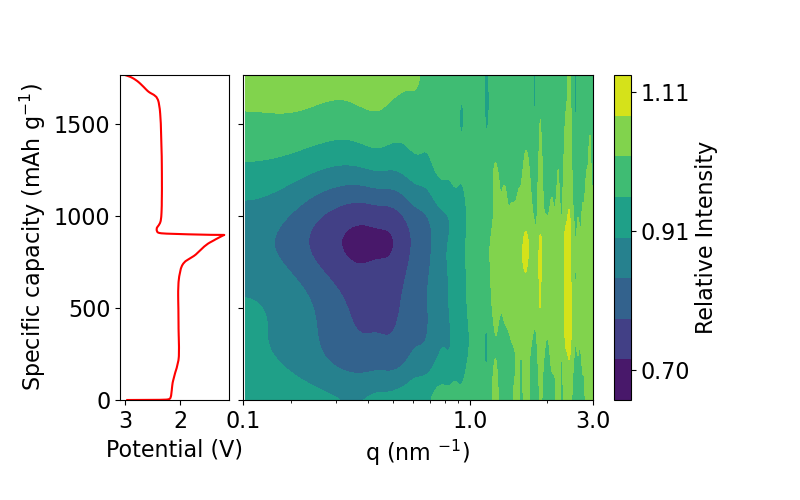

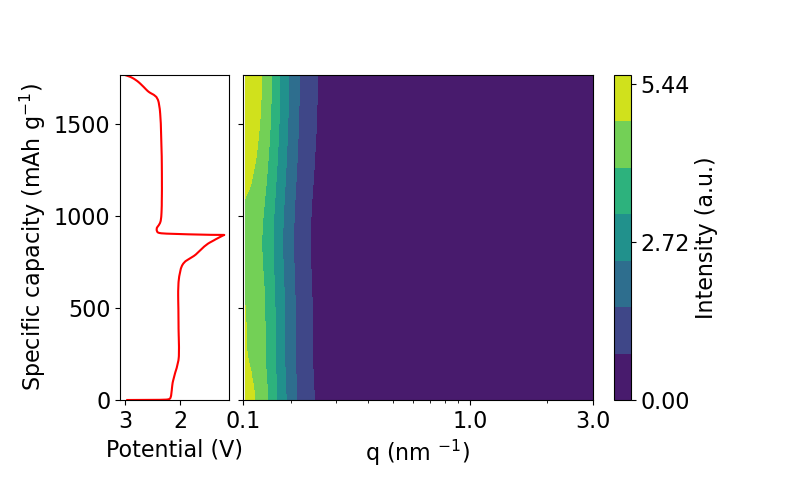

In [12]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 2, end_cycle = 2, plot= False)
contourplot('saxs', 'relative', file_dictionary, new_time_dict, saxs_min_limit, 3, Normalization_file= starting_file, save_plot = False, filename ="satDME.png")
contourplot('saxs', 'absolute', file_dictionary, new_time_dict, saxs_min_limit, saxs_max_limit)

# Background correction with empty cell subtraction 

File used for background: EmptyCell_0_00000_2D_sum_azimAvg_to_be_used.dat


(0.01, 6)

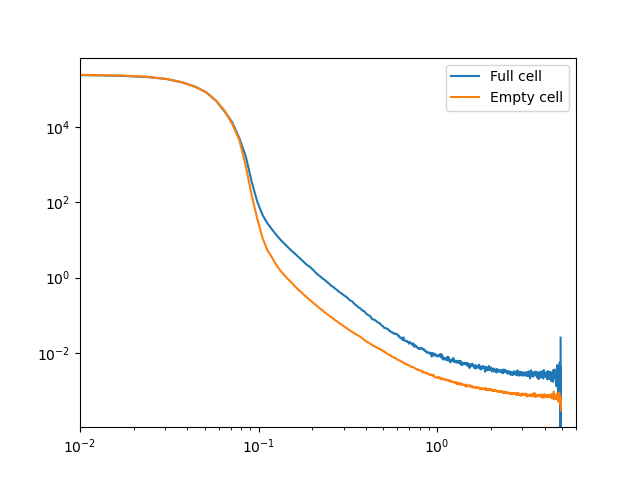

In [13]:
os.chdir(r'\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\EmptyCell\Data-reduced')
saxs_background_file =  glob.glob('EmptyCell_0_00000_2D_sum_azimAvg_to_be_used.dat')#glob.glob('20240730_Empty_Cell_saxs.dat')
#print(file_list)

for file in saxs_background_file:
    a1,a2,SAXS_background = read_data(file)

plt.figure()  
print('File used for background:',file)

plt.plot(10*file_dictionary[1].iloc[:,0],file_dictionary[1].iloc[:,1], label = 'Full cell')
plt.plot(10*SAXS_background.iloc[:,0], SAXS_background.iloc[:,1], label = 'Empty cell')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(0.01,6)
#plt.ylim(0.001,40)
#print(SAXS_background)
# print(file_dictionary[1].head())
# print(file_dictionary[250].head())

# Create a new dictionary with corrected SAXS

(0.0001, 40)

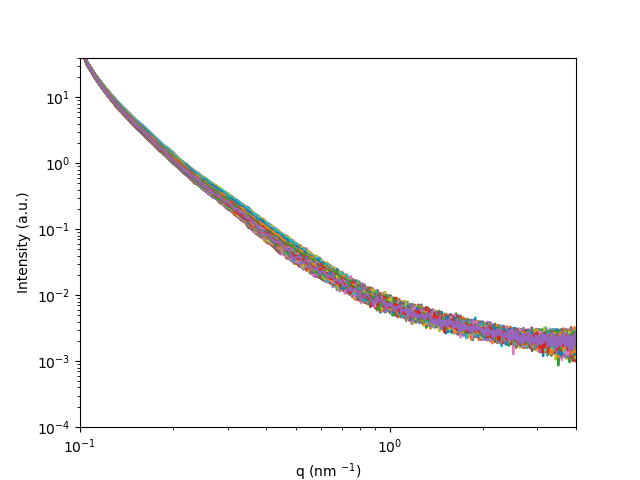

In [14]:
plt.figure()
emptyCell_corrected_saxs_files = {}
for ikey in file_dictionary:
    X_data = file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - SAXS_background.iloc[:len(Y_data),1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_saxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,4)
plt.ylim(0.0001,40)
#print(corrected_waxs_files[1].head(30))


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]
Normalized with - 55


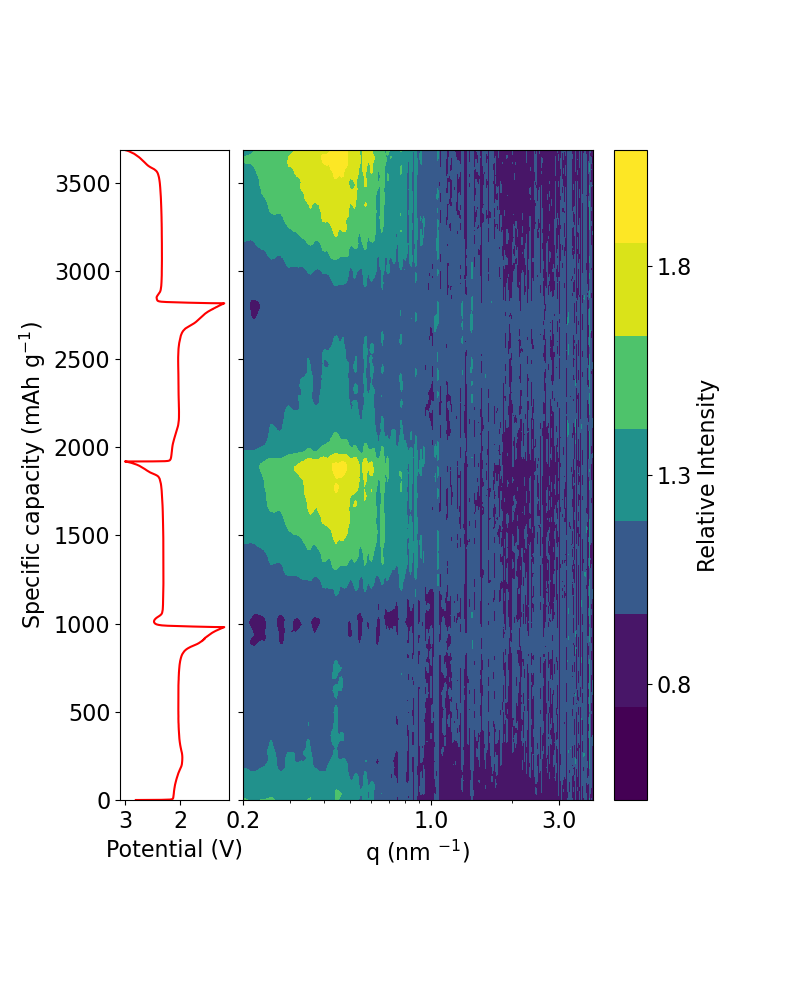

In [138]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 2, plot= False)
print(f'Normalized with - {discharge_file}')
#contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.14, 4,  Normalization_file= discharge_file, save_plot= False)
contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.2, 4, Normalization_file= discharge_file, save_plot= False, cmap_min= 0.85, cmap_max=1.75, scientific= False, decimal_points= 1)

# Manual correction with perticular curve

# WAXS data polotting

In [15]:
directory_path = r'\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\cell3'
os.chdir(directory_path)
file_list_waxs = glob.glob('*_1_*.dat')
#print(file_list)


legend_waxs = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp_waxs = {} #Dictionary to store the time of file creation
key = 0
file_dictionary_waxs = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list_waxs:
    key += 1
    legend_waxs[key], time_stamp_waxs[key], file_dictionary_waxs[key] = read_data(data_file)
    
print('Number of files:',key)


Number of files: 385


# Plot the WAXS data

In [16]:
file_min = starting_file  # Start index of the files to plot
file_max = last_file  # End index of the files to plot

plt.figure()
plt.style.use('default')

# Get 'viridis' colormap
cmap = plt.get_cmap('viridis')
files_to_plot = list(file_dictionary_waxs.keys())[file_min:file_max+1]  # Select keys in the specified range
num_files = len(files_to_plot)
colors = cmap(np.linspace(0, 1, num_files))  # Generate a range of colors for each selected file

# Plot each file in the specified range
for idx, (ikey, color) in enumerate(zip(files_to_plot, colors)):
    X_data = 10 * file_dictionary_waxs[ikey].iloc[:, 0]  # Convert from inverse Å to inverse nm
    Y_data = file_dictionary_waxs[ikey].iloc[:, 1]
    plt.plot(2 * np.degrees(np.arcsin((0.154 * X_data) / (4 * np.pi))), 
             Y_data*1000, color=color, label=f"File {ikey}") # 0.154, wavelenght of Cu K alpha

# Setting graph attributes
plt.xlim(12,35)
plt.ylim(2,7)
plt.xlabel('2θ (°)', fontsize = 20)
plt.ylabel('Intensity (a.u.)', fontsize = 20)
#plt.yticks([])
plt.tick_params(labelsize = 20)


NameError: name 'starting_file' is not defined


Biologic data file line details:
Line numbers for each electrochemical change event : [8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [106, 155, 202]


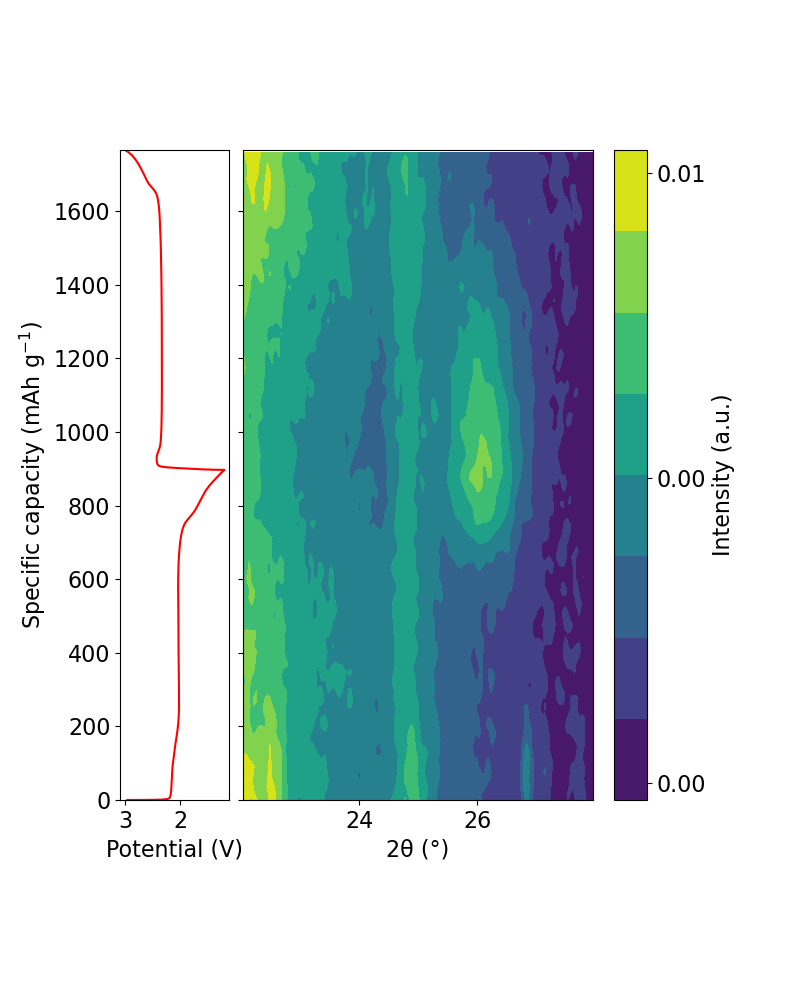

In [17]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 2, end_cycle = 2, plot= False)
contourplot('waxs', 'absolute', file_dictionary_waxs, new_time_dict, 22, 28, cmap_min= None, cmap_max= None)

# Background correction and plotting for the WAXS

# Background correction with empty cell subtraction 

File used for WAXS background: waxs_corrected_with_mask.dat


Text(0, 0.5, 'Intensity (a.u.)')

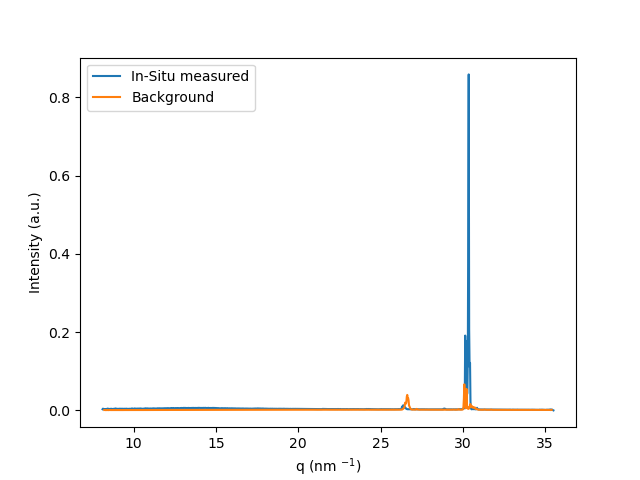

In [18]:
directory_path = r'\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\EmptyCell'
os.chdir(directory_path)
waxs_background_file =  glob.glob('waxs_corrected_with_mask.dat')
#glob.glob('20240730_Empty_Cell_waxs.dat')
WAXS_background = {} # Dictionary for storing all the pandas data file 

for file in waxs_background_file:
    a1,a2,WAXS_background = read_data(file)
    
print('File used for WAXS background:', file)
plt.figure()
plt.plot(10*file_dictionary_waxs[1].iloc[:,0], file_dictionary_waxs[1].iloc[:,1], label = "In-Situ measured")
plt.plot(10*WAXS_background.iloc[:,0], WAXS_background.iloc[:,1], label = 'Background')
plt.legend()
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

(-0.02, 0.05)

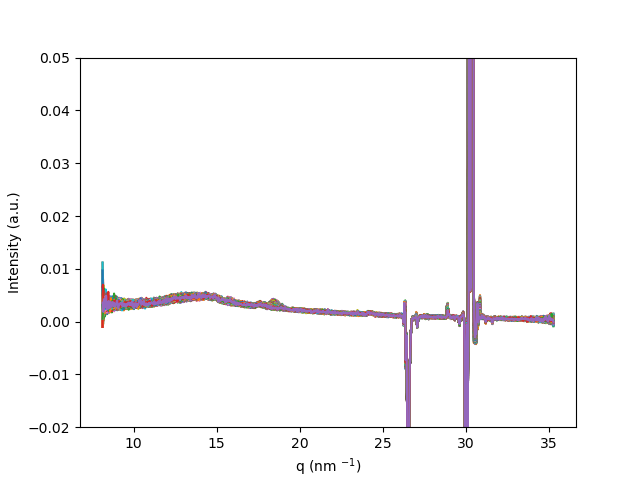

In [19]:
plt.figure()
emptyCell_corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - WAXS_background.iloc[:,1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02,0.05)
#print(corrected_waxs_files[1].head(30))

# Empty cell subtraction by matching peak at 9.68 

In [ ]:
plt.figure()
emptyCell_corrected_waxs_files2 = {}

for ikey in file_dictionary_waxs:
    # Extract X and Y data for the current file
    X_data = file_dictionary_waxs[ikey].iloc[:, 0]
    Y_data = file_dictionary_waxs[ikey].iloc[:, 1]
    
    # Interpolate Y values at X = 9.68 for both Y_data and WAXS_background
    target_X = 3.4
    if X_data.min() <= target_X <= X_data.max():
        Y_value_at_target = np.interp(target_X, X_data, Y_data)
        background_Y_value_at_target = np.interp(target_X, WAXS_background.iloc[:, 0], WAXS_background.iloc[:, 1])

        # Calculate the difference to align the background
        offset = Y_value_at_target - background_Y_value_at_target
        aligned_WAXS_background = WAXS_background.iloc[:, 1] + offset

        # Now subtract the aligned background from the raw Y_data
        modified_Y = Y_data - aligned_WAXS_background
#        plt.plot(10 * X_data, file_dictionary_waxs[ikey].iloc[:,1], label=f"raw {ikey}")
 #       plt.plot(10 * X_data, aligned_WAXS_background, label=f"background {ikey}")
        plt.plot(10 * X_data, modified_Y, label=f"Corrected {ikey}")

        # Store the results in the dictionary
        df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
        emptyCell_corrected_waxs_files2[ikey] = df
    else:
        print(f"Target X value {target_X} is out of range for file {ikey}")

# Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02, 0.05)
plt.show()


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


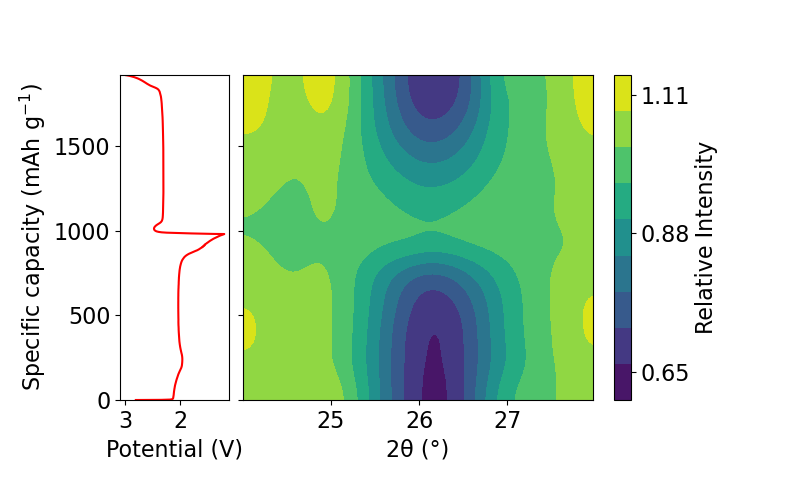

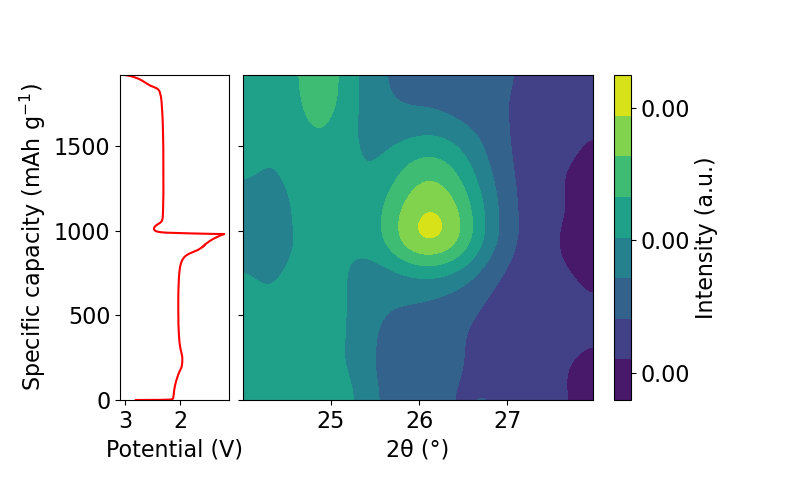

NameError: name 'emptyCell_corrected_waxs_files2' is not defined

In [65]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 1, plot= False)
contourplot('waxs', 'relative', emptyCell_corrected_waxs_files, new_time_dict, 24, 28, cmap_min= None , cmap_max= None, Normalization_file= discharge_file)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files, new_time_dict, 24, 28, cmap_min= None , cmap_max= None, save_plot= True)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files2, new_time_dict, 15, waxs_max_limit, cmap_min= None, cmap_max= None)

# Background correction with a polynomial (correction with only one background file)

In [ ]:
X_data = []
Y_data = []

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary_waxs[files].iloc[:,1]
    else:
        x = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary_waxs[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

output_filename = "corrected_waxs.txt"
with open(output_filename, 'w') as f:
    for x,y in zip(X_data, modified_Y):
        f.write(f"{x}\t{y}\n")

print(f"first file printed as {output_filename}")

# Create background corrected WAXS dataframe

plt.figure("After polynomial background correction")

corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#print(corrected_waxs_files[1].head(30))


# Correction with polynomial background on individual files 

In [20]:
corrected_individual_waxs_files = {}
X_data = file_dictionary_waxs[ikey].iloc[:, 0]
# filter the range for the WAXS
filtered_X_range_min = np.max(np.where(X_data <= 1.4))
filtered_X_range_max = np.max(np.where(X_data <= 2.5))
# print(empty_cell_corrected_waxs_files)
print(f"filtered position: {filtered_X_range_min}, {filtered_X_range_max}, value: {X_data[filtered_X_range_min]}, {X_data[filtered_X_range_max]}")

for ikey in file_dictionary_waxs:
    min_val = 0
    max_val = 0
    modified_Y = 0
    X2_values = file_dictionary_waxs[ikey].iloc[filtered_X_range_min:filtered_X_range_max,0] 
    Y1_values = file_dictionary_waxs[ikey].iloc[filtered_X_range_min:filtered_X_range_max,1]
    
    # define baselines for individual files and subtract from the data
    baseline_filter = Baseline(x_data = X2_values)
    baseline = baseline_filter.modpoly(Y1_values, poly_order= 3)[0]
    modified_Y = Y1_values - baseline
    plt.plot(X2_values, modified_Y)
    # Smooth the data
    #smoothed_Y = smooth_data(modified_Y, window_length=11, polyorder=2)

    # min_val = np.min(smoothed_Y)
    # max_val = np.max(smoothed_Y)
    #normalized_Y = smoothed_Y #'(smoothed_Y - min_val)/(max_val - min_val)' # Normalized the data between [0,1]
    df = pd.DataFrame({'X_data': X2_values, 'Modified_Y': modified_Y}) # change the 'Modified_Y' as per the requirement, raw, smoothened or smoothened plus normalized 
    corrected_individual_waxs_files[ikey] = df

filtered position: 220, 633, value: 1.3957449456344977, 2.496877061292659


# Colour plot of Background corrected WAXS

profile for cycle number: 1 to 1

Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]


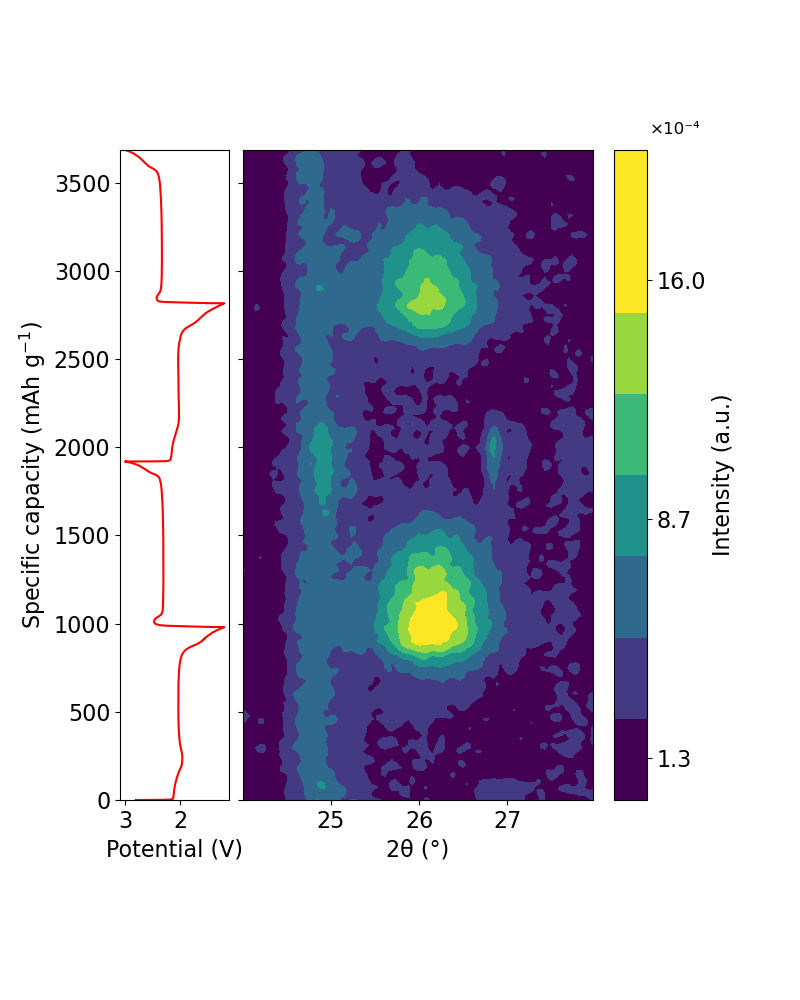

In [21]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 2, plot= False)
contourplot('waxs', 'absolute', corrected_individual_waxs_files, new_time_dict, 24, 28,  save_plot= True,  cmap_min= 1.3e-4, cmap_max= 16e-4, decimal_points=1,scientific=True)

# Waterfall plot for SAXS


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


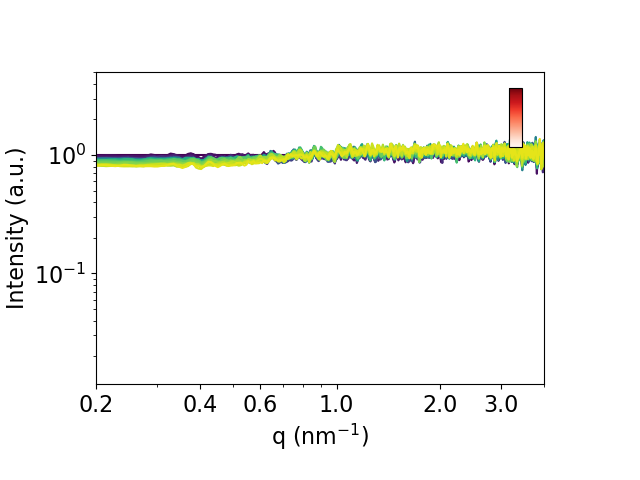

\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\EmptyCell
53


In [22]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import numpy as np

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=1, plot=False)

file_list = file_dictionary
# Set up normalization for color mapping
norm_discharging = Normalize(vmin=starting_file + 4, vmax=discharge_file)

# Define axis limits and labels
x_lim_min, x_lim_max = 0.2, 4
y_lim_min, y_lim_max = 0.0015, 2
fntsize = 16

fig, ax = plt.subplots()

# --- Plot: Discharging ---
for file_number in range(starting_file + 4, discharge_file - 1):
    X_data = 10 * file_list[file_number].iloc[:, 0]  # Convert nm^-1
    Y_data = file_list[file_number].iloc[:, 1]  / file_list[starting_file + 4].iloc[:, 1]

    # Filter the data to have better smoothing and plotting
    X_mask = X_data > x_lim_min
    X_data = X_data[X_mask]
    Y_data = Y_data[X_mask]

    # Mask all the sudden drops in the data to avoid sharp peaks
    mask = Y_data > 0.000
    X_data = X_data[mask]
    Y_data = Y_data[mask]

    # Apply Savitzky-Golay smoothing
    if len(Y_data) > 11:  # Ensure enough points for filtering
        Y_savgol = savgol_filter(Y_data, window_length=10, polyorder=4)
    else:
        Y_savgol = Y_data  # If too few points, use raw data

    # Apply multiplicative offset for better visualization in log scale
    offset = 1.02 ** (file_number - (starting_file + 4))  # Normalize offset
    Y_savgol = Y_savgol #* offset  # Multiply instead of adding

    # Ensure no zero values (important for log scale)
    Y_savgol[Y_savgol <= 0] = np.min(Y_savgol[Y_savgol > 0]) * 0.1

    # Define color
    color = cm.viridis(norm_discharging(file_number))
    
    # Plot the curve
    ax.plot(X_data, Y_savgol, label=str(time_stamp[file_number]), color=color)

ax.set_xlim(x_lim_min, x_lim_max)
#ax.set_ylim(y_lim_min, y_lim_max)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(labelsize=fntsize)
ax.set_xlabel('q (nm$^{-1}$)', fontsize=fntsize)
ax.set_ylabel('Intensity (a.u.)', fontsize=fntsize)

ax.set_xticks([0.2, 0.4, 0.6, 1.0, 2.0, 3.0])
ax.set_xticklabels(['0.2', '0.4', '0.6', '1.0', '2.0', '3.0'], fontsize=fntsize)

# --- Colorbar ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm_discharging)
sm.set_array([])
axins = inset_axes(ax, width="3%", height="20%", loc='upper right',
                   bbox_to_anchor=(0, 0, 0.95, 0.95),
                   bbox_transform=ax.transAxes, borderpad=0)
cbar = plt.colorbar(sm, cax=axins)
cbar.set_ticks([])

# Adjust layout
fig.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.2)

# Save and Show
plt.savefig("discharging1.png", dpi=600, format='png')
plt.show()

print(os.getcwd())
print(file_number)



Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


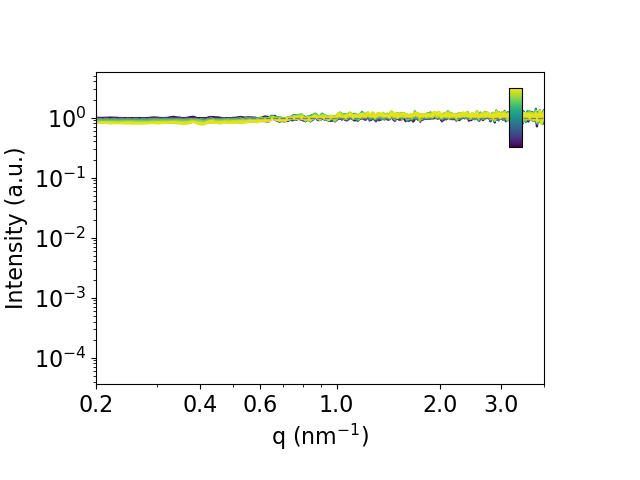

\\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\EmptyCell
53


In [23]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Get data
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=1, plot=False)
file_list = file_dictionary

# Color normalization
norm_discharging = Normalize(vmin=starting_file + 4, vmax=discharge_file)

# Plot setup
x_lim_min, x_lim_max = 0.2, 4
fntsize = 16
fig, ax = plt.subplots()

# === Get and smooth the reference curve ===
ref_Y = file_list[starting_file + 4].iloc[:, 1].values
ref_Y = savgol_filter(ref_Y, window_length=11, polyorder=4)
ref_Y[ref_Y <= 0] = np.min(ref_Y[ref_Y > 0]) * 0.1

# === Plotting loop ===
for file_number in range(starting_file + 4, discharge_file - 1):
    X_data = 10 * file_list[file_number].iloc[:, 0].values  # Convert q to nm^-1
    Y_data = file_list[file_number].iloc[:, 1].values

    # Smooth Y_data
    if len(Y_data) > 11:
        Y_data = savgol_filter(Y_data, window_length=11, polyorder=4)

    # Avoid zero values
    Y_data[Y_data <= 0] = np.min(Y_data[Y_data > 0]) * 0.1

    # Normalize against reference
    Y_norm = Y_data / ref_Y
    Y_norm[Y_norm <= 0] = np.min(Y_norm[Y_norm > 0]) * 0.1

    # Mask q-range and valid intensity
    mask = (X_data > x_lim_min) & (Y_norm > 0)
    X_data = X_data[mask]
    Y_norm = Y_norm[mask]

    # Offset to visually separate curves
    offset = 1.03 ** (file_number - (starting_file + 4))
   # Y_norm *= offset

    # Colormap and plot
    color = cm.viridis(norm_discharging(file_number))
    ax.plot(X_data, Y_norm, color=color)

# === Axes settings ===
ax.set_xlim(x_lim_min, x_lim_max)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(labelsize=fntsize)
ax.set_xlabel('q (nm$^{-1}$)', fontsize=fntsize)
ax.set_ylabel('Intensity (a.u.)', fontsize=fntsize)

ax.set_xticks([0.2, 0.4, 0.6, 1.0, 2.0, 3.0])
ax.set_xticklabels(['0.2', '0.4', '0.6', '1.0', '2.0', '3.0'], fontsize=fntsize)

# === Optional horizontal reference line at y=1 ===
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

# === Colorbar ===
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_discharging)
sm.set_array([])
axins = inset_axes(ax, width="3%", height="20%", loc='upper right',
                   bbox_to_anchor=(0, 0, 0.95, 0.95),
                   bbox_transform=ax.transAxes, borderpad=0)
cbar = plt.colorbar(sm, cax=axins)
cbar.set_ticks([])

# Layout
fig.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.2)

# Save + show
plt.savefig("discharging1_enhanced.png", dpi=600, format='png')
plt.show()

print(os.getcwd())
print(file_number)


# Manually plot certain saxs and waxs file

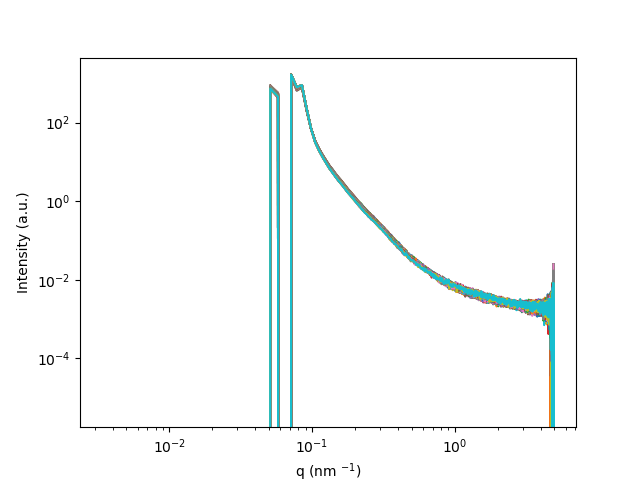

In [117]:
# Manual data plotting SAXS
plt.figure()

for ikey in range(5,55):
    X_data = 10*emptyCell_corrected_saxs_files[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

plt.xscale('log')
plt.yscale('log')

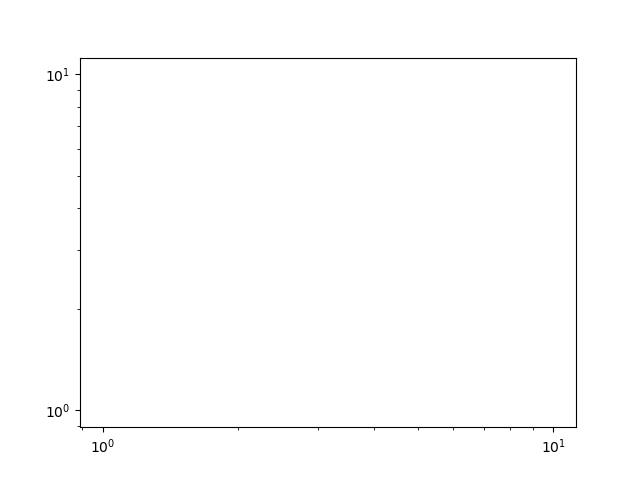

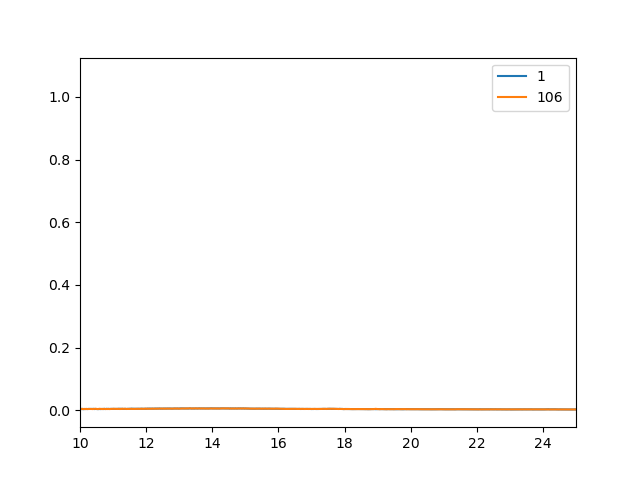

In [141]:
# Manual data plotting WAXS
plt.figure()
for ikey in range(106,106):
    X_data = 10*emptyCell_corrected_saxs_files[169].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[169].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xscale('log')
plt.yscale('log')
plt.figure()
for ikey in [1,106]:
    X_data = 10*file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    plt.plot(X_data, Y_data, label= ikey)
    plt.xlim(10,25)
plt.legend()

# Find average intensity within a certain q range


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]


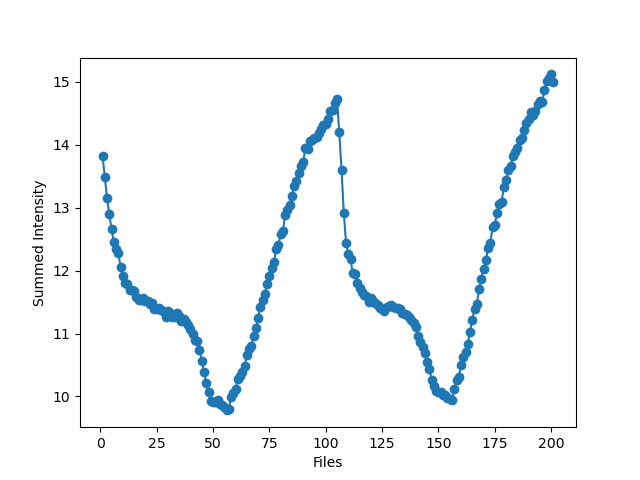

In [27]:

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 2, plot= False)
# Initialize the figure
plt.figure()

# Initialize data
fileset_dictionary = emptyCell_corrected_saxs_files
intensity_dictionary = {}
q_min_nm = 0.2
q_max_nm = 0.5

# Convert x-axis data for sample
x_sample_data = 10 * fileset_dictionary[1].iloc[:, 0]  # Converted from inverse Å to nm
key1 = np.where((x_sample_data <= q_max_nm) & (x_sample_data >= q_min_nm))[0]

# Iterate through each file and accumulate intensity within the range
for idx, file in enumerate(range(starting_file, last_file)):
    intensity_temp = 0
    for entry in key1:
        intensity_temp += fileset_dictionary[file].iloc[entry, 1]  # Assuming intensity is in column 1

    # Save intensity and plot it
    intensity_dictionary[file] = intensity_temp
      # Scatter plot with `idx` as x-axis position
x_values = list(intensity_dictionary.keys())      # File names or identifiers as x-axis labels
y_values = list(intensity_dictionary.values())
plt.plot(x_values, y_values, marker='o')
# Finalize the plot
plt.xlabel('Files')
plt.ylabel('Summed Intensity')
#plt.xticks(range(len(fileset_dictionary)), list(fileset_dictionary.keys()), rotation=90)  # Label x-axis with file names
plt.show()



# 3D waterfall plot for WAXS 


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Files numbers for SAXS data [1, 55, 106]


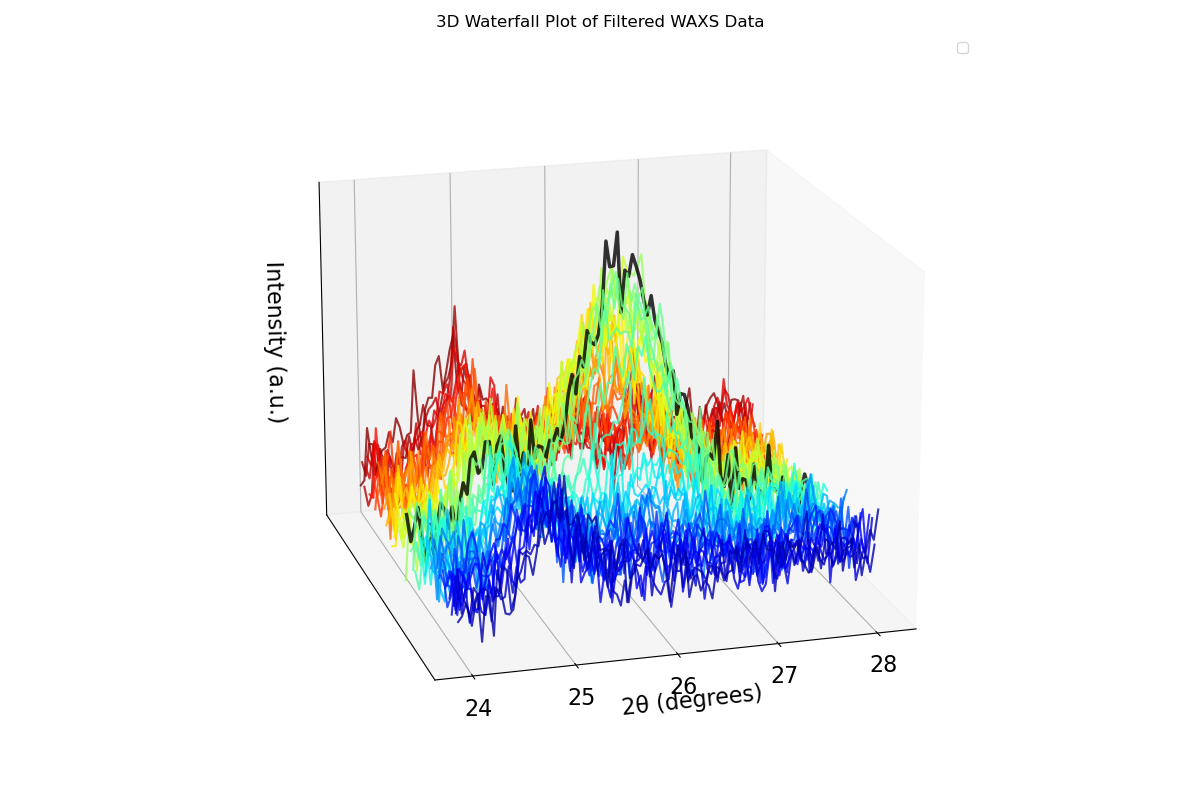

In [120]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 1, plot= False)

# Assuming data_to_plot, starting_file, last_file, saxs_file_numbers, and discharge_file are defined
data_to_plot = corrected_individual_waxs_files

# Wavelength for Cu Kα in nm
wavelength = 0.15406  # nm

# Function to convert q (nm^-1) to 2theta (degrees)
def q_to_two_theta(q_values, wavelength):
    return 2 * np.degrees(np.arcsin((q_values * wavelength) / (4 * np.pi)))

# Initialize the figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
plt.title("3D Waterfall Plot of Filtered WAXS Data")

# Define filtering limits
q_min, q_max = 16.9, 19.8
intensity_min, intensity_max = 0, 0.02  # Adjust as necessary

# Base offset for the waterfall plot
base_offset = 0.0
offset_increment = 0.000002  # Smaller value to improve spacing

# Set transparency
transparency = 0.8

# List of keys and reverse it
keys = list(range(starting_file+4, last_file + 1, 2))
keys.reverse()

# Ensure discharge_file is included in keys
if discharge_file not in keys:
    keys.append(discharge_file)
    keys = sorted(keys, reverse=True)  # Keep keys in reverse order for consistency

# Adjust the saxs_file_numbers list to exclude the first and last entries
#adjusted_saxs_file_numbers = saxs_file_numbers[1:-1]

for ikey in keys:
    # Extract X and Y values
    original_q = 10 * data_to_plot[ikey].iloc[:, 0]  # q values in nm^-1
    original_Y = data_to_plot[ikey].iloc[:, 1]  # Intensity values
    
    # Convert q to 2theta
    converted_two_theta = q_to_two_theta(original_q, wavelength)
    
    # Filter data based on limits
    filtered_indices = (original_q >= q_min) & (original_q <= q_max) #& (original_Y >= intensity_min) & (original_Y <= intensity_max)
    filtered_two_theta = converted_two_theta[filtered_indices]
    filtered_Y = original_Y[filtered_indices]
    
    # Apply vertical offset for Z-axis
    offset = base_offset + (ikey - starting_file) * offset_increment
    Z = np.full_like(filtered_two_theta, offset)
    
    # Check if the current file is the discharge file
    if ikey == discharge_file:
        # Plot the discharge file in black and bold
        ax.plot(filtered_two_theta, Z, filtered_Y, 
                color='black', linewidth=2.5, alpha=transparency)
    else:
        # Plot other files with default style
        ax.plot(filtered_two_theta, Z, filtered_Y, 
                color=cm.jet((ikey - starting_file) / (last_file - starting_file)), 
                alpha=transparency)

# Set axis labels
ax.set_xlabel('2θ (degrees)',fontsize=16)  # Update x-axis label to 2theta
ax.tick_params(axis='x', labelsize=16)
ax.set_yticks([])  # Hide y-ticks for offset
ax.set_zticks([])  # Hide z-ticks for intensity
ax.set_zlabel('Intensity (a.u.)', fontsize=16)  # Update z-axis label to intensity


# Add legend for discharge file
ax.legend(loc="upper right")

# Adjust view angle
ax.view_init(elev=18, azim=-106)

# Show plot
plt.tight_layout()
plt.show()


# 2D WAXS waterfall plot 

C:\Users\b1104371\AppData\Local\Temp\ipykernel_5592\4126213457.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues', num_curves)
C:\Users\b1104371\AppData\Local\Temp\ipykernel_5592\4126213457.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


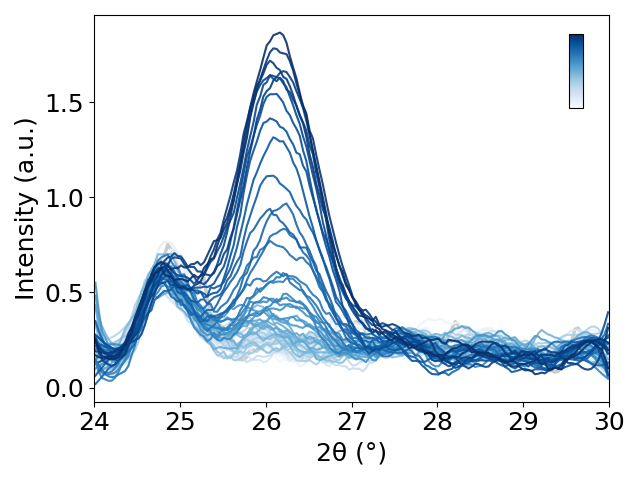

the plot is saved in the directory \\shares.is.sbg.ac.at\GFS_EML\SAXS_Backup\inhouse\ChristianP\KBS_operandoSAXS_29012025\EmptyCell


In [131]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import os 

# Function to convert q (nm^-1) to 2theta (degrees)
def q_to_two_theta(q_values, wavelength):
    return 2 * np.degrees(np.arcsin((q_values * wavelength) / (4 * np.pi)))

# Wavelength for Cu Kα in nm
wavelength = 0.15406  # nm

# Define filtering limits
q_min, q_max = 16.96, 21.12
intensity_min, intensity_max = 0, 0.02  # Adjust as necessary

# Create figure for 2D waterfall plot
fig, ax = plt.subplots()
#ax.set_title("2D Waterfall Plot of WAXS Data (Smoothed)", fontsize=16)

# Base offset for the 2D stacked plot
offset_increment = 0.00001  # Adjust to control spacing

# List of keys and reverse them for waterfall effect
keys = list(range(starting_file+0, discharge_file + 1))
#keys.reverse()

# Ensure discharge_file is included in keys
if discharge_file not in keys:
    keys.append(discharge_file)
    keys = sorted(keys, reverse=False)  # Keep keys in reverse order for consistency

# Define color gradient for normal curves (Greyscale)
num_curves = len(keys)
cmap = cm.get_cmap('Blues', num_curves)

for idx, ikey in enumerate(keys):
    # Extract X and Y values from actual data
    original_q = 10 * data_to_plot[ikey].iloc[:, 0]  # q values in nm^-1
    original_Y = data_to_plot[ikey].iloc[:, 1]  # Intensity values

    # Convert q to 2theta
    converted_two_theta = q_to_two_theta(original_q, wavelength)

    # Filter data based on limits
    valid_indices = (original_q >= q_min) & (original_q <= q_max) & (original_Y >= intensity_min) & (original_Y <= intensity_max)
    filtered_two_theta = converted_two_theta[valid_indices]
    filtered_Y = original_Y[valid_indices]

    # Apply Savitzky-Golay filtering for smoothing (window=7, polynomial order=3)
    if len(filtered_Y) > 7:  # Ensure enough points for filtering
        smoothed_Y = savgol_filter(filtered_Y, window_length=20, polyorder=3)*1000
    else:
        smoothed_Y = filtered_Y *1000 # If too few points, use raw data

    # Apply vertical offset for stacked appearance
    offset = idx * offset_increment

    # Check if the current file is the discharge file
    if ikey == starting_file+0:
        # **Discharge file in bold black**
        ax.plot(filtered_two_theta, savgol_filter(filtered_Y, window_length=10, polyorder=2)*1000 + offset, color='black', linewidth=2.5, alpha=0.2)
    else:
        # **Other curves in fading grayscale**
        ax.plot(filtered_two_theta, smoothed_Y + offset, color=cmap(idx / num_curves), alpha=0.9)


# Colorbar inside top-right corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create ScalarMappable for colorbar
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm_discharging)
sm.set_array([])

# Positioning colorbar inside plot (top right corner)
axins = inset_axes(ax, width="3%", height="20%", loc='upper right',
                   bbox_to_anchor=(0, 0, 0.95, 0.95),
                   bbox_transform=ax.transAxes, borderpad=0)

cbar = plt.colorbar(sm, cax=axins)
cbar.set_ticks([])

# Set axis labels
ax.set_xlim(24, 30)
ax.set_xlabel('2θ (°)', fontsize=18)
ax.set_ylabel('Intensity (a.u.)', fontsize=18)
ax.tick_params(axis='both', labelsize=18) 
# Remove y-ticks for a cleaner waterfall effect
#ax.set_yticks([])

# Add legend for discharge curve
#ax.legend(loc="upper right", fontsize=12)

# Adjust layout and show plot
plt.tight_layout()
plt.show()
plt.savefig("2D_Waterfall_Plot_WAXS.png", dpi=600, format='png')
print(f'the plot is saved in the directory {os.getcwd()}')